In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# 1. Copia do Drive (note o MyDrive) para o disco local do Colab
!cp "/content/drive/MyDrive/dataset.zip" "/content/"

# 2. Extrai o arquivo (note o /content/ antes do dataset.zip)
!7z x /content/dataset.zip -o/content/


7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.00GHz (50653),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan /content/                   1 file, 705976966 bytes (674 MiB)

Extracting archive: /content/dataset.zip
 52% 4096 Open              --
Path = /content/dataset.zip
Type = zip
Physical Size = 705976966

  0%    
Would you like to replace the existing file:
  Path:     /content/dataset/.gitignore
  Size:     2 bytes (1 KiB)
  Modified: 2026-04-06 16:34:20
with the file from archive:
  Path:     dataset/.gitignore
  Size:     2 bytes (1 KiB)
  Modified: 2026-04-06 16:34:20
? (Y)es / (N)o / (A)lways / (S)kip all / A(u)to rename all / (Q)uit? q

Archives with Errors: 1



Break signaled


In [4]:
!pip install pytorch-lightning torchinfo torchmetrics torch-summary torchmetrics medmnist

In [5]:
import multiprocessing as mp
import os
import random
import sys
from glob import glob

import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import pytorch_lightning as pl
import torch
from sklearn.metrics import classification_report
from glob import glob
import torchinfo
import torch.nn as nn
from medmnist import DermaMNIST
from pytorch_lightning.callbacks import ModelCheckpoint
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from torch import nn
from torch.optim import AdamW
from torch.utils.data import DataLoader, TensorDataset
from torch.utils.data import random_split
from torchmetrics import Accuracy
from torchsummary import summary
from torchvision import models
from torchvision import datasets, models
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.transforms import ToTensor
from torchvision.utils import make_grid

In [6]:
class EfeitosDataModule(pl.LightningDataModule):
    def __init__(
        self,
        data_dir: str = '/dataset', # Caminho para a pasta principal
        batch_size: int = 32,               # Tamanho do lote
        num_workers: int = 2,               # Threads para carregar os dados
        img_size: int = 256,                # Tamanho da imagem
        val_split: float = 0.2              # Porcentagem de dados para validação (20%)
    ):
        super().__init__()

        # Salva todos os argumentos do __init__ em self.hparams
        self.save_hyperparameters()

        # Define as transformações baseadas nos hiperparâmetros
        self.transform = transforms.Compose([
            transforms.Resize((self.hparams.img_size, self.hparams.img_size)),
            transforms.ToTensor()
        ])

    def setup(self, stage=None):
        """
        O setup é chamado em cada GPU (se você usar mais de uma).
        É aqui que dividimos o dataset em Treino e Validação/Teste.
        """
        dataset_completo = ImageFolder(root=self.hparams.data_dir, transform=self.transform)

        # Calcula a quantidade de imagens para treino e validação
        tamanho_total = len(dataset_completo)
        tamanho_val = int(self.hparams.val_split * tamanho_total)
        tamanho_treino = tamanho_total - tamanho_val

        # random_split garante que as imagens sejam separadas aleatoriamente
        self.dataset_treino, self.dataset_val = random_split(
            dataset_completo,
            [tamanho_treino, tamanho_val],
            generator=torch.Generator().manual_seed(42)
        )

    def train_dataloader(self):
        # Retorna o DataLoader de treino (com shuffle=True)
        return DataLoader(
            self.dataset_treino,
            batch_size=self.hparams.batch_size,
            shuffle=True,
            num_workers=self.hparams.num_workers,
            pin_memory=True # Acelera a transferência para a GPU no Colab
        )

    def val_dataloader(self):
        # Retorna o DataLoader de validação (com shuffle=False)
        return DataLoader(
            self.dataset_val,
            batch_size=self.hparams.batch_size,
            shuffle=False,
            num_workers=self.hparams.num_workers,
            pin_memory=True
        )

In [16]:
data_module = EfeitosDataModule(
    data_dir='/content/dataset',
    batch_size=64,
    img_size=224
)

data_module.setup()

# Pegando informações para conferir
print(f"Imagens para treino: {len(data_module.dataset_treino)}")
print(f"Imagens para validação: {len(data_module.dataset_val)}")

# Pegando um batch de validação para teste
dataloader_val = data_module.val_dataloader()
imagens, labels = next(iter(dataloader_val))
print(f"Shape do batch de imagens: {imagens.shape}")

Imagens para treino: 6149
Imagens para validação: 1537
Shape do batch de imagens: torch.Size([64, 3, 224, 224])


In [18]:



class CNNEfeitos(pl.LightningModule):
    def __init__(self, num_classes: int, lr: float = 1e-3):
        super().__init__()
        self.save_hyperparameters()

        # Modelo do zero
        self.modelo = models.resnet18(weights=None)
        num_features = self.modelo.fc.in_features
        self.modelo.fc = nn.Linear(num_features, self.hparams.num_classes)

        self.criterio = nn.CrossEntropyLoss()

        # Instanciando o TorchMetrics para multiclasse
        self.acuracia = Accuracy(task="multiclass", num_classes=self.hparams.num_classes)

    def forward(self, x):
        return self.modelo(x)

    def training_step(self, batch, batch_idx):
        imagens, labels = batch
        previsoes = self(imagens)
        loss = self.criterio(previsoes, labels)

        self.log('loss_treino', loss, prog_bar=True, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        imagens, labels = batch
        previsoes = self(imagens)
        loss = self.criterio(previsoes, labels)

        acc = self.acuracia(previsoes, labels)

        self.log('loss_val', loss, prog_bar=True, on_epoch=True)
        self.log('acc_val', acc, prog_bar=True, on_epoch=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.lr)

In [23]:
from pytorch_lightning.callbacks import ModelCheckpoint

NUM_EFEITOS = len(data_module.dataset_treino.dataset.classes)

#Configurando checkpoint
checkpoint_callback = ModelCheckpoint(
    dirpath='logs_melhor_modelo/', # Pasta onde ele vai salvar
    filename='cnn-efeitos-{epoch:02d}-{acc_val:.2f}', # Nome do arquivo dinâmico
    monitor='acc_val', # Métrica que ele deve ficar vigiando
    mode='max',        # Queremos o modelo com a acurácia máx
    save_top_k=1       # Salva apenas o Top 1 (apaga os piores para poupar disco)
)

modelo = CNNEfeitos(num_classes=NUM_EFEITOS, lr=0.001)

trainer = pl.Trainer(
    max_epochs=30,
    accelerator='auto',
    devices='auto',
    log_every_n_steps=10,
    callbacks=[checkpoint_callback]
)

print("Iniciando treinamento com ModelCheckpoint ativo...")
trainer.fit(model=modelo, datamodule=data_module)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /content/logs_melhor_modelo exists and is not empty.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Iniciando treinamento com ModelCheckpoint ativo...


┏━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name     ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ modelo   │ ResNet             │ 11.2 M │ train │     0 │
│ 1 │ criterio │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ acuracia │ MulticlassAccuracy │      0 │ train │     0 │
└───┴──────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 11.2 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 11.2 M                                                                                               
Total estimated model params size (MB): 44                                                                         
Modules in train mode: 70                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=30` reached.


Calculando previsões no dataset de validação...


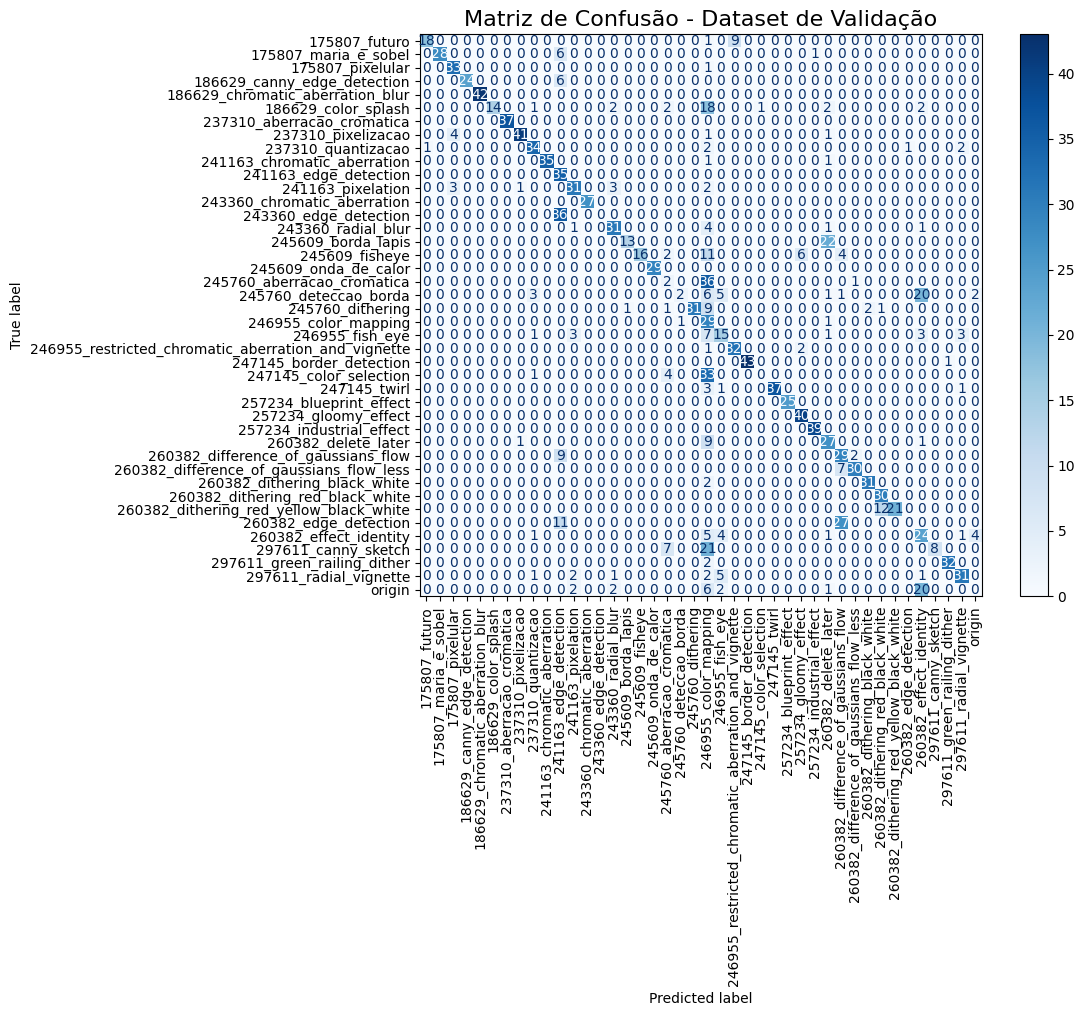

In [24]:
modelo.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
modelo.to(device)

todas_preds = []
todas_labels = []

print("Calculando previsões no dataset de validação...")

# Desliga o cálculo de gradientes (economiza memória e deixa muito mais rápido)
with torch.no_grad():
    for imagens, labels in data_module.val_dataloader():
        imagens = imagens.to(device)

        # Faz a previsão
        previsoes = modelo(imagens)
        preds = torch.argmax(previsoes, dim=1)

        # Salva para a matriz
        todas_preds.extend(preds.cpu().numpy())
        todas_labels.extend(labels.numpy())

#Pega os nomes reais das classes (efeitos)
nomes_classes = data_module.dataset_treino.dataset.classes

#Gera e plota a Matriz de Confusão
cm = confusion_matrix(todas_labels, todas_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nomes_classes)

fig, ax = plt.subplots(figsize=(12, 10))
disp.plot(ax=ax, cmap='Blues', xticks_rotation='vertical')

plt.title("Matriz de Confusão - Dataset de Validação", fontsize=16)
plt.tight_layout()
plt.show()

In [25]:


# Busca o modelo salvo pelo ModelCheckpoint
caminhos_checkpoints = glob("logs_melhor_modelo/*.ckpt")
caminho_campeao = caminhos_checkpoints[0] # Pega o arquivo salvo

print(f"Gerando relatório com o modelo campeão: {caminho_campeao}")

# Carrega o modelo do disco e manda para a GPU
modelo_campeao = CNNEfeitos.load_from_checkpoint(caminho_campeao).eval()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
modelo_campeao = modelo_campeao.to(device)

# Coleta as previsões da validação de forma otimizada (em lotes)
todas_preds = []
todas_labels = []

with torch.no_grad():
    for imagens, labels in data_module.val_dataloader():
        imagens = imagens.to(device)

        previsoes = modelo_campeao(imagens)
        preds = torch.argmax(previsoes, dim=1)

        todas_preds.extend(preds.cpu().numpy())
        todas_labels.extend(labels.numpy())

nomes_classes = data_module.dataset_treino.dataset.classes

print("\n" + "="*60)
print("RELATÓRIO DE CLASSIFICAÇÃO DETALHADO - CNN")
print("="*60)
relatorio = classification_report(
    todas_labels,
    todas_preds,
    target_names=nomes_classes,
    digits=4 # Mostra 4 casas decimais para maior precisão
)
print(relatorio)

Gerando relatório com o modelo campeão: logs_melhor_modelo/cnn-efeitos-epoch=19-acc_val=0.67.ckpt

RELATÓRIO DE CLASSIFICAÇÃO DETALHADO - CNN
                                                     precision    recall  f1-score   support

                                      175807_futuro     1.0000    0.9286    0.9630        28
                               175807_maria_e_sobel     1.0000    0.8571    0.9231        35
                                   175807_pixelular     0.7381    0.9118    0.8158        34
                        186629_canny_edge_detection     0.9667    0.9667    0.9667        30
                   186629_chromatic_aberration_blur     1.0000    0.9048    0.9500        42
                                186629_color_splash     0.3333    0.1429    0.2000        42
                         237310_aberracao_cromatica     1.0000    1.0000    1.0000        37
                                 237310_pixelizacao     0.7414    0.9149    0.8190        47
                    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [1]:
def extrair_dados_para_ml(dataloader):
    imagens_achatadas = []
    labels_lista = []

    print("Extraindo imagens do DataLoader...")
    for imagens, labels in dataloader:
        batch_size = imagens.size(0)

        # Achata a imagem: O -1 faz o PyTorch calcular automaticamente o tamanho final
        imagens_flat = imagens.view(batch_size, -1).numpy()

        imagens_achatadas.append(imagens_flat)
        labels_lista.append(labels.numpy())

    # Junta todas as listas em uma matriz única do NumPy
    X = np.vstack(imagens_achatadas)
    y = np.concatenate(labels_lista)

    return X, y

# Pegamos o dataloader de treino do seu DataModule
dataloader_treino = data_module.train_dataloader()
X_treino, y_treino = extrair_dados_para_ml(dataloader_treino)

print(f"Formato de X_treino: {X_treino.shape}")
print(f"Formato de y_treino: {y_treino.shape}")

NameError: name 'data_module' is not defined

In [ ]:
# Crie isso antes da função do PCA, se a memória estourar
data_module_ml = EfeitosDataModule(
    data_dir='/content/dataset',
    batch_size=32,
    img_size=64
)
data_module_ml.setup()
X_treino, y_treino = extrair_dados_para_ml(data_module_ml.train_dataloader())

In [ ]:
print("Calculando o PCA (Isso pode levar alguns segundos/minutos dependendo da RAM)...")

# Instancia o PCA pedindo 50 componentes
pca = PCA(n_components=50, random_state=42)

X_treino_pca = pca.fit_transform(X_treino)

print(f"Formato após o PCA: {X_treino_pca.shape}")